In [5]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
protein = "VCAM1"

In [7]:
vgat_geph_results_file = f"/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/{protein}/{protein}-LacZ_VGAT-GEPH_output_data/metric_results.csv"
vgat_geph_results = pd.read_csv(vgat_geph_results_file)
vgat_geph_results

,Unnamed: 0,img_filename,local_peak_colocalized_spots,local_peak_colocalized_spots_rot,overlap_coeff,overlap_coeff_rot,overlap_um2,overlap_um2_rot,pearson_cor,pvalue,...,postsynapse_image_mfi,pre_puncta_density_per_100_um2,post_puncta_density_per_100_um2,pre_staining_area_um2,post_staining_area_um2,pre_mean_puncta_size_um2,post_mean_puncta_size_um2,gRNA,hippocampal_layer,Brain
0,0,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_LacZ-...,48,10,0.155255,0.032665,6.883428,1.448246,0.255541,0.0,...,199.862944,16.532498,8.652007,61.032492,25.066581,0.203442,0.159660,LacZ-gRNA,CA3 SO,Brain-4-2
1,1,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_VCAM1...,16,7,0.148589,0.043393,12.059629,3.521793,0.166916,0.0,...,256.204743,62.603057,24.357880,121.853710,48.500905,0.107266,0.109731,VCAM1-gRNA,CA1 SLM,Brain-4-2
2,2,CRISPR-Exp5_IHC-Exp7_Brain-7_section-1_LacZ-gR...,47,3,0.149219,0.034030,8.248187,1.881016,0.220473,0.0,...,161.937354,64.146090,11.572748,116.905820,22.674420,0.100435,0.107973,LacZ-gRNA,DG ML,Brain-7
3,3,CRISPR-Exp5_IHC-Exp7_Brain-7_section-2_LacZ-gR...,40,7,0.142098,0.017769,4.823511,0.603152,0.208208,0.0,...,181.818659,16.146739,5.235291,61.511265,14.741440,0.209936,0.155173,LacZ-gRNA,CA3 SO,Brain-7
4,4,CRISPR-Exp4_IHC-Exp7_Brain-4_section-3_LacZ-gR...,34,11,0.194297,0.043563,15.821661,3.547351,0.245212,0.0,...,278.558761,51.140526,27.058188,108.562219,54.356930,0.116985,0.110707,LacZ-gRNA,CA1 SLM,Brain-4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,171,CRISPR-Exp4_IHC-Exp7_Brain-4_section-2_VCAM1-g...,59,14,0.229095,0.039123,14.806185,2.528467,0.248884,0.0,...,190.967989,13.777081,16.532498,50.959515,63.986913,0.203838,0.213290,VCAM1-gRNA,CA3 SR,Brain-4
172,172,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-3_LacZ-...,35,5,0.099158,0.029285,4.021012,1.187562,0.160338,0.0,...,142.060966,80.678588,5.180183,152.357177,9.415302,0.104069,0.100163,LacZ-gRNA,DG ML,Brain-4-2
173,173,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_VCAM1...,5,0,0.198776,0.041028,8.890526,1.835013,0.306157,0.0,...,130.883171,8.266249,7.935599,44.946739,32.912667,0.299645,0.228560,VCAM1-gRNA,DG Hilus,Brain-4-2
174,174,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_LacZ-...,75,11,0.234714,0.041852,19.387754,3.457048,0.281830,0.0,...,199.935429,23.090388,16.201848,84.265764,61.737873,0.201112,0.209993,LacZ-gRNA,CA3 SR,Brain-4-2


In [8]:
vgat_geph_results["target"] = vgat_geph_results["gRNA"].str.cat(vgat_geph_results[["Brain"]], sep = "_")

In [9]:
vgat_geph_results

,Unnamed: 0,img_filename,local_peak_colocalized_spots,local_peak_colocalized_spots_rot,overlap_coeff,overlap_coeff_rot,overlap_um2,overlap_um2_rot,pearson_cor,pvalue,...,pre_puncta_density_per_100_um2,post_puncta_density_per_100_um2,pre_staining_area_um2,post_staining_area_um2,pre_mean_puncta_size_um2,post_mean_puncta_size_um2,gRNA,hippocampal_layer,Brain,target
0,0,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_LacZ-...,48,10,0.155255,0.032665,6.883428,1.448246,0.255541,0.0,...,16.532498,8.652007,61.032492,25.066581,0.203442,0.159660,LacZ-gRNA,CA3 SO,Brain-4-2,LacZ-gRNA_Brain-4-2
1,1,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_VCAM1...,16,7,0.148589,0.043393,12.059629,3.521793,0.166916,0.0,...,62.603057,24.357880,121.853710,48.500905,0.107266,0.109731,VCAM1-gRNA,CA1 SLM,Brain-4-2,VCAM1-gRNA_Brain-4-2
2,2,CRISPR-Exp5_IHC-Exp7_Brain-7_section-1_LacZ-gR...,47,3,0.149219,0.034030,8.248187,1.881016,0.220473,0.0,...,64.146090,11.572748,116.905820,22.674420,0.100435,0.107973,LacZ-gRNA,DG ML,Brain-7,LacZ-gRNA_Brain-7
3,3,CRISPR-Exp5_IHC-Exp7_Brain-7_section-2_LacZ-gR...,40,7,0.142098,0.017769,4.823511,0.603152,0.208208,0.0,...,16.146739,5.235291,61.511265,14.741440,0.209936,0.155173,LacZ-gRNA,CA3 SO,Brain-7,LacZ-gRNA_Brain-7
4,4,CRISPR-Exp4_IHC-Exp7_Brain-4_section-3_LacZ-gR...,34,11,0.194297,0.043563,15.821661,3.547351,0.245212,0.0,...,51.140526,27.058188,108.562219,54.356930,0.116985,0.110707,LacZ-gRNA,CA1 SLM,Brain-4,LacZ-gRNA_Brain-4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,171,CRISPR-Exp4_IHC-Exp7_Brain-4_section-2_VCAM1-g...,59,14,0.229095,0.039123,14.806185,2.528467,0.248884,0.0,...,13.777081,16.532498,50.959515,63.986913,0.203838,0.213290,VCAM1-gRNA,CA3 SR,Brain-4,VCAM1-gRNA_Brain-4
172,172,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-3_LacZ-...,35,5,0.099158,0.029285,4.021012,1.187562,0.160338,0.0,...,80.678588,5.180183,152.357177,9.415302,0.104069,0.100163,LacZ-gRNA,DG ML,Brain-4-2,LacZ-gRNA_Brain-4-2
173,173,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_VCAM1...,5,0,0.198776,0.041028,8.890526,1.835013,0.306157,0.0,...,8.266249,7.935599,44.946739,32.912667,0.299645,0.228560,VCAM1-gRNA,DG Hilus,Brain-4-2,VCAM1-gRNA_Brain-4-2
174,174,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_LacZ-...,75,11,0.234714,0.041852,19.387754,3.457048,0.281830,0.0,...,23.090388,16.201848,84.265764,61.737873,0.201112,0.209993,LacZ-gRNA,CA3 SR,Brain-4-2,LacZ-gRNA_Brain-4-2


In [10]:
df2_grouped_brain = vgat_geph_results.groupby(["target", "hippocampal_layer"], as_index=False)[["local_peak_colocalized_spots",
                                        "overlap_coeff",
                                        "overlap_um2",
                                        "pearson_cor",
                                        "presynapse_image_mfi",
                                        "postsynapse_image_mfi",
                                        "pre_puncta_density_per_100_um2",
                                        "post_puncta_density_per_100_um2",
                                        "pre_staining_area_um2",
                                        "post_staining_area_um2",
                                        "pre_mean_puncta_size_um2",
                                        "post_mean_puncta_size_um2"]].mean()

In [11]:
df_grouped_section = vgat_geph_results[["target",
                                        "hippocampal_layer",
                                        "img_filename",
                                        "local_peak_colocalized_spots",
                                        "overlap_coeff",
                                        "overlap_um2",
                                        "pearson_cor",
                                        "presynapse_image_mfi",
                                        "postsynapse_image_mfi",
                                        "pre_puncta_density_per_100_um2",
                                        "post_puncta_density_per_100_um2",
                                        "pre_staining_area_um2",
                                        "post_staining_area_um2",
                                        "pre_mean_puncta_size_um2",
                                        "post_mean_puncta_size_um2"]]
final_df = df_grouped_section.reset_index()

In [12]:
# to long format
df_melted = df2_grouped_brain.melt(id_vars=['target', 'hippocampal_layer'], var_name='metric', value_name='value')

# create new column based on hippocampal layer and metric
df_melted['hippocampal_layer_metric'] = df_melted['hippocampal_layer'] + '_' + df_melted['metric']

# pivot the dataframe back
df_pivot = df_melted.pivot(index='target', columns='hippocampal_layer_metric', values='value')

final_df = df_pivot.reset_index()

In [13]:
features = list(final_df.columns)
columns_to_remove = ["index", "target", "hippocampal_layer", "img_filename"]

for column in columns_to_remove:
    if column in features:  # Check if the column exists in the list
        features.remove(column)

print(features)

['CA1 SLM_local_peak_colocalized_spots', 'CA1 SLM_overlap_coeff', 'CA1 SLM_overlap_um2', 'CA1 SLM_pearson_cor', 'CA1 SLM_post_mean_puncta_size_um2', 'CA1 SLM_post_puncta_density_per_100_um2', 'CA1 SLM_post_staining_area_um2', 'CA1 SLM_postsynapse_image_mfi', 'CA1 SLM_pre_mean_puncta_size_um2', 'CA1 SLM_pre_puncta_density_per_100_um2', 'CA1 SLM_pre_staining_area_um2', 'CA1 SLM_presynapse_image_mfi', 'CA1 SO_local_peak_colocalized_spots', 'CA1 SO_overlap_coeff', 'CA1 SO_overlap_um2', 'CA1 SO_pearson_cor', 'CA1 SO_post_mean_puncta_size_um2', 'CA1 SO_post_puncta_density_per_100_um2', 'CA1 SO_post_staining_area_um2', 'CA1 SO_postsynapse_image_mfi', 'CA1 SO_pre_mean_puncta_size_um2', 'CA1 SO_pre_puncta_density_per_100_um2', 'CA1 SO_pre_staining_area_um2', 'CA1 SO_presynapse_image_mfi', 'CA1 SR_local_peak_colocalized_spots', 'CA1 SR_overlap_coeff', 'CA1 SR_overlap_um2', 'CA1 SR_pearson_cor', 'CA1 SR_post_mean_puncta_size_um2', 'CA1 SR_post_puncta_density_per_100_um2', 'CA1 SR_post_staining_ar

In [14]:
# separating out the features
X = final_df.loc[:,features].values
# separating out the target
Y = final_df.loc[:,["target"]].values

In [15]:
scaled_data = StandardScaler().fit_transform(X)

In [16]:
pca = PCA()
pca.fit_transform(scaled_data)

array([[-8.57140109e+00,  2.27232398e+00, -1.85624644e+00,
         3.50074185e+00, -6.68852665e-01, -1.03158334e+00,
        -3.63320686e+00, -9.89778641e-16],
       [ 4.06726944e+00, -3.14905121e+00, -6.71507581e+00,
         4.21288578e+00, -1.40929461e+00,  9.22042413e-01,
         2.01706973e+00, -9.89778641e-16],
       [ 5.74951321e-01,  9.60231086e+00,  1.73837659e+00,
         8.15694873e-01,  1.32657756e+00,  3.13003595e+00,
         1.61389510e+00, -9.89778641e-16],
       [ 5.51703011e+00, -1.67041660e-02, -2.01500694e+00,
        -2.40884408e+00,  5.75788563e+00, -2.21784858e+00,
        -1.43313855e+00, -9.89778641e-16],
       [-9.59332838e+00, -4.67930587e+00,  1.01266656e+00,
        -2.40171358e+00,  1.98312196e+00,  5.51121228e-02,
         2.94331994e+00, -9.89778641e-16],
       [ 2.15669012e+00, -3.47531000e+00,  3.02746441e-01,
        -4.70568133e+00, -2.30079519e+00,  4.02205020e+00,
        -2.40982865e+00, -9.89778641e-16],
       [ 1.70806129e+00,  3.388694

In [17]:
pca.explained_variance_ratio_

array([3.09278834e-01, 2.19125624e-01, 1.43004327e-01, 1.27719099e-01,
       8.67074819e-02, 6.51563285e-02, 4.90083054e-02, 1.02048100e-32])

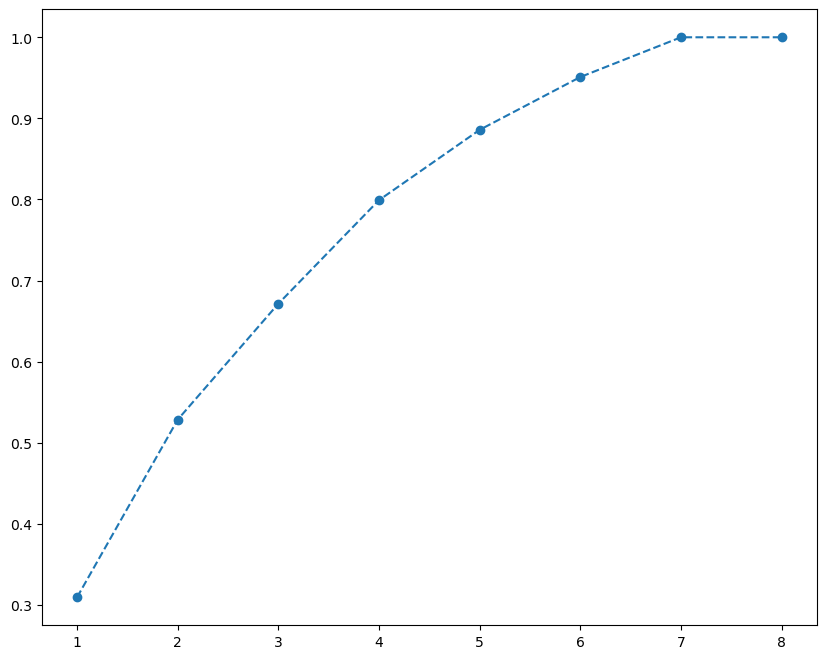

In [18]:
plt.figure(figsize=(10,8))
plt.plot(range(1,9), pca.explained_variance_ratio_.cumsum(), marker = "o", linestyle = "--")

In [19]:
pca = PCA(n_components=4)
comps = pca.fit_transform(scaled_data)

In [20]:
pca_df = pd.DataFrame(data=comps, columns= ["PC1", "PC2", "PC3", "PC4"])

In [21]:
pca_df = pd.concat([pca_df, final_df[['target']]], axis = 1)
pca_df.head(10)

,PC1,PC2,PC3,PC4,target
0,-8.571401,2.272324,-1.856246,3.500742,LacZ-gRNA_Brain-4
1,4.067269,-3.149051,-6.715076,4.212886,LacZ-gRNA_Brain-4-2
2,0.574951,9.602311,1.738377,0.815695,LacZ-gRNA_Brain-5
3,5.517030,-0.016704,-2.015007,-2.408844,LacZ-gRNA_Brain-7
4,-9.593328,-4.679306,1.012667,-2.401714,VCAM1-gRNA_Brain-4
5,2.156690,-3.475310,0.302746,-4.705681,VCAM1-gRNA_Brain-4-2
6,1.708061,3.388694,0.250555,-3.581963,VCAM1-gRNA_Brain-5
7,4.140727,-3.942958,7.281984,4.568879,VCAM1-gRNA_Brain-7


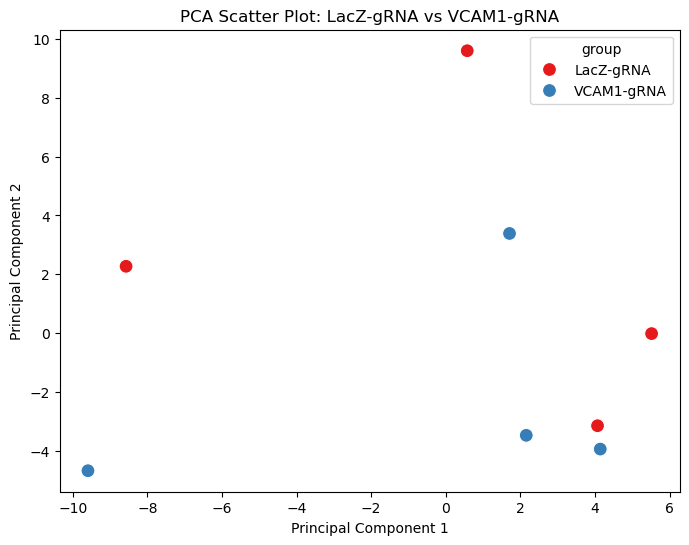

In [49]:
# Step 1: Create a new column to group targets into "LacZ-gRNA" and "VCAM1-gRNA"
pca_df['group'] = pca_df['target'].apply(lambda x: 'LacZ-gRNA' if 'LacZ' in x else 'VCAM1-gRNA')

# Step 2: Create a scatter plot using Seaborn
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x='PC1', 
    y='PC2', 
    hue='group',  # Use the new 'group' column for coloring
    palette='Set1',  # Set1 is a good palette for distinct colors
    s=100  # Marker size
)

# Add title and labels
plt.title('PCA Scatter Plot: LacZ-gRNA vs VCAM1-gRNA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Show the plot
plt.show()

In [50]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_pca_static(pca_results, labels=None, explained_var=None, output_file='pca_3d_plot.png'):
    """
    Create a static 3D PCA plot and save it to a file
    
    Parameters:
    pca_results: DataFrame with columns PC1, PC2, PC3
    labels: array-like with group labels (optional)
    explained_var: list of 3 values with explained variance for first 3 PCs (optional)
    output_file: str, path to save the plot (default: 'pca_3d_plot.png')
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Create scatter plot
    if labels is not None:
        # Plot with different colors for each group
        for label in labels.unique():
            mask = labels == label
            ax.scatter(
                pca_results.loc[mask, 'PC1'],
                pca_results.loc[mask, 'PC2'],
                pca_results.loc[mask, 'PC3'],
                label=label,
                alpha=0.7
            )
        plt.legend()
    else:
        # Plot all points in single color
        ax.scatter(
            pca_results['PC1'],
            pca_results['PC2'],
            pca_results['PC3'],
            alpha=0.7
        )
    
    # Set labels
    if explained_var:
        ax.set_xlabel(f'PC1 ({explained_var[0]:.1f}%)')
        ax.set_ylabel(f'PC2 ({explained_var[1]:.1f}%)')
        ax.set_zlabel(f'PC3 ({explained_var[2]:.1f}%)')
    else:
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_zlabel('PC3')
    
    plt.title('3D PCA Plot')
    
    # Save the plot
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.close()

# Example usage:
plot_3d_pca_static(
    pca_results=pca_df,
    labels=pca_df['group'],
    explained_var=[30.5, 20.1, 15.2],
    output_file='pca_3d_plot.png'
)

In [23]:
scores_pca = pca.transform(scaled_data)
scores_pca

array([[-8.57140109,  2.27232398, -1.85624644,  3.50074185],
       [ 4.06726944, -3.14905121, -6.71507581,  4.21288578],
       [ 0.57495132,  9.60231086,  1.73837659,  0.81569487],
       [ 5.51703011, -0.01670417, -2.01500694, -2.40884408],
       [-9.59332838, -4.67930587,  1.01266656, -2.40171358],
       [ 2.15669012, -3.47531   ,  0.30274644, -4.70568133],
       [ 1.70806129,  3.38869412,  0.25055523, -3.58196278],
       [ 4.14072721, -3.94295771,  7.28198438,  4.56887926]])

In [24]:
# K-means based on PC's
wcss = []
for i in range(1,9):
    kmeans_pca = KMeans(n_clusters = i, init = "k-means++", random_state= 42)
    kmeans_pca.fit(scores_pca)
    wcss.append(kmeans_pca.inertia_)

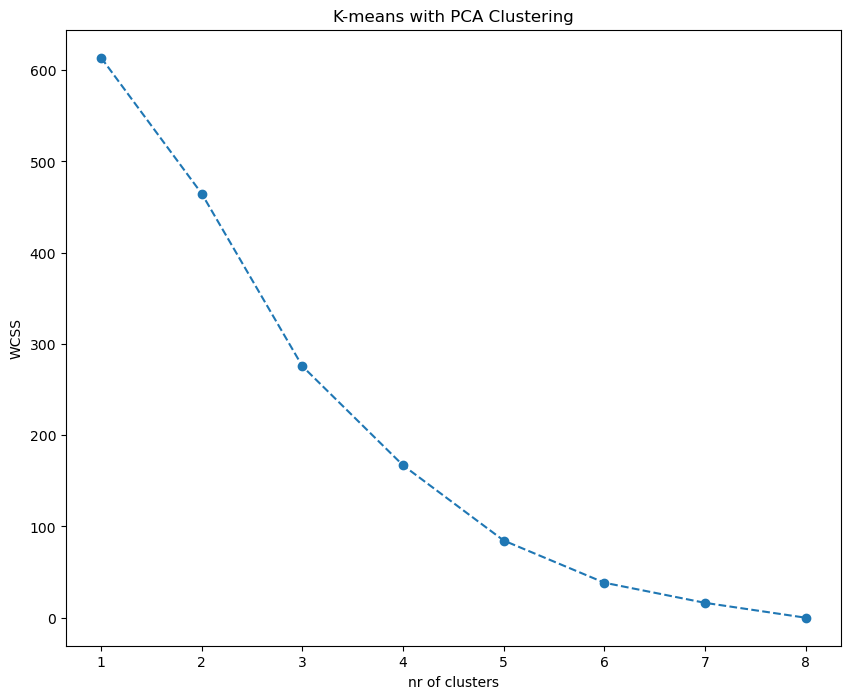

In [25]:
plt.figure(figsize=(10,8))
plt.plot(range(1,9), wcss, marker = "o", linestyle = "--")
plt.xlabel("nr of clusters")
plt.ylabel("WCSS")
plt.title("K-means with PCA Clustering")
plt.show()

In [32]:
kmeans_pca = KMeans(n_clusters = 3, init = "k-means++", random_state=42)

In [33]:
kmeans_pca.fit(scores_pca)

KMeans(n_clusters=3, random_state=42)

In [34]:
df_data_pca_kmeans = pd.concat([final_df.reset_index(drop=True), pd.DataFrame(scores_pca)], axis =1)
df_data_pca_kmeans.columns.values[-4:] = ["PC1", "PC2", "PC3", "PC4"]
df_data_pca_kmeans["Segment K-Means PCA"] = kmeans_pca.labels_
df_data_pca_kmeans

,target,CA1 SLM_local_peak_colocalized_spots,CA1 SLM_overlap_coeff,CA1 SLM_overlap_um2,CA1 SLM_pearson_cor,CA1 SLM_post_mean_puncta_size_um2,CA1 SLM_post_puncta_density_per_100_um2,CA1 SLM_post_staining_area_um2,CA1 SLM_postsynapse_image_mfi,CA1 SLM_pre_mean_puncta_size_um2,...,DG ML_postsynapse_image_mfi,DG ML_pre_mean_puncta_size_um2,DG ML_pre_puncta_density_per_100_um2,DG ML_pre_staining_area_um2,DG ML_presynapse_image_mfi,PC1,PC2,PC3,PC4,Segment K-Means PCA
0,LacZ-gRNA_Brain-4,27.666667,0.199567,13.225041,0.262538,0.110781,23.016910,46.266630,236.547826,0.116441,...,148.069555,0.104199,56.137014,106.009899,223.099682,-8.571401,2.272324,-1.856246,3.500742,2
1,LacZ-gRNA_Brain-4-2,31.666667,0.176516,14.979974,0.224199,0.105471,25.184505,48.215799,255.884256,0.111254,...,142.818637,0.102346,69.509967,129.255098,232.386719,4.067269,-3.149051,-6.715076,4.212886,1
2,LacZ-gRNA_Brain-5,31.666667,0.187125,15.772818,0.240997,0.110580,24.835485,49.804894,251.617380,0.110698,...,177.989779,0.103411,76.196444,142.973111,244.970842,0.574951,9.602311,1.738377,0.815695,0
3,LacZ-gRNA_Brain-7,21.500000,0.165961,15.647020,0.195657,0.108314,26.562213,52.206710,238.478268,0.109134,...,154.907051,0.102993,71.282618,133.552981,262.514879,5.517030,-0.016704,-2.015007,-2.408844,1
4,VCAM1-gRNA_Brain-4,24.666667,0.201412,12.311226,0.261285,0.109988,22.814847,45.551026,224.377269,0.117409,...,163.396543,0.106614,37.087903,72.179442,221.825783,-9.593328,-4.679306,1.012667,-2.401714,2
5,VCAM1-gRNA_Brain-4-2,18.000000,0.166313,12.740021,0.205371,0.107534,22.484197,43.910249,245.690543,0.111462,...,166.480213,0.105542,60.582419,115.923852,227.854521,2.156690,-3.475310,0.302746,-4.705681,1
6,VCAM1-gRNA_Brain-5,27.333333,0.181874,15.984092,0.227859,0.106860,26.029499,50.568205,244.995550,0.114417,...,171.308024,0.103966,81.744016,154.229106,217.872236,1.708061,3.388694,0.250555,-3.581963,1
7,VCAM1-gRNA_Brain-7,11.500000,0.161279,14.725254,0.179594,0.106122,25.873359,49.811993,214.064503,0.110209,...,159.285315,0.106944,66.818844,129.686164,241.440437,4.140727,-3.942958,7.281984,4.568879,1


In [ ]:
import umap

In [ ]:
reducer = umap.UMAP()

In [ ]:
embedding = reducer.fit_transform(scaled_data)
embedding.shape

In [ ]:
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[sns.color_palette()[x] for x in final_df.target.map({"LacZ-gRNA_Brain-4":0, 
                                                            "LacZ-gRNA_Brain-4-2":1, 
                                                            "LacZ-gRNA_Brain-5":0,
                                                            "LacZ-gRNA_Brain-7":0,
                                                            "VCAM1-gRNA_Brain-4":1,
                                                            "VCAM1-gRNA_Brain-4-2":1,
                                                            "VCAM1-gRNA_Brain-5":1,
                                                            "VCAM1-gRNA_Brain-7":1})])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP ', fontsize=24);

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Corrected label mapping
label_map = {
    "CA1 SLM_VCAM1-gRNA": 0, 
    "CA1 SLM_LacZ-gRNA": 1, 
    "CA1 SR_VCAM1-gRNA": 2, 
    "CA1 SR_LacZ-gRNA": 3,
    "CA1 SO_VCAM1-gRNA": 4, 
    "CA1 SO_LacZ-gRNA": 5, 
    "CA3 SO_VCAM1-gRNA": 6, 
    "CA3 SO_LacZ-gRNA": 7,
    "CA3 SL_VCAM1-gRNA": 8, 
    "CA3 SL_LacZ-gRNA": 9, 
    "CA3 SR_VCAM1-gRNA": 10, 
    "CA3 SR_LacZ-gRNA": 11,
    "DG Hilus_VCAM1-gRNA": 12, 
    "DG Hilus_LacZ-gRNA": 13,
    "DG ML_VCAM1-gRNA": 14, 
    "DG ML_LacZ-gRNA": 15
}

label_map_gRNA = {
    "VCAM1-gRNA": 0, 
    "LacZ-gRNA": 1
}

# Generate base colors for each layer
base_colors = sns.color_palette("husl", n_colors=2)

# Create color palette with slight variations for VCAM1 and LacZ
colors = []
for base_color in base_colors:
    # Slightly darker color for VCAM1-gRNA
    colors.append(tuple(max(0, c - 0.1) for c in base_color))
    # Slightly lighter color for LacZ-gRNA
    colors.append(tuple(min(1, c + 0.1) for c in base_color))

# Map the labels to colors
color_values = [colors[x] for x in vglut1_psd95_results.gRNA.map(label_map_gRNA)]

# Create a larger plot with smaller dots
plt.figure(figsize=(8, 8))  # Increase the plot size

# Plot the scatter points
scatter = plt.scatter(
    embedding[:, 0],  # X-axis values
    embedding[:, 1],  # Y-axis values
    c=color_values,   # Colors based on mapped labels
    s=15             # Dot size, reduced for smaller dots
)

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP Visualization', fontsize=24)

# Create a legend manually
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, 
                      markerfacecolor=colors[i], markersize=10) 
           for label, i in label_map_gRNA.items()]
plt.legend(handles=handles, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

plt.tight_layout()
plt.show()

